## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re, ast
from datasets import load_dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## Load dataset from HF

In [ ]:
dataset = load_dataset("librarian-bots/model_cards_with_metadata")

README.md:   0%|          | 0.00/5.89k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/268M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/266M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/265M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650931 [00:00<?, ? examples/s]

## Inspect dataset

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['modelId', 'author', 'last_modified', 'downloads', 'likes', 'library_name', 'tags', 'pipeline_tag', 'createdAt', 'card'],
        num_rows: 650931
    })
})


In [ ]:
train = dataset["train"]

In [ ]:
train.column_names

['modelId',
 'author',
 'last_modified',
 'downloads',
 'likes',
 'library_name',
 'tags',
 'pipeline_tag',
 'createdAt',
 'card']

In [ ]:
train[0]

{'modelId': 'myfi/parser_model_ner_3.85',
 'author': 'myfi',
 'last_modified': datetime.datetime(2025, 12, 12, 6, 42, 11, tzinfo=<UTC>),
 'downloads': 2,
 'likes': 0,
 'library_name': 'transformers',
 'tags': ['transformers',
  'safetensors',
  'qwen3',
  'text-generation',
  'text-generation-inference',
  'unsloth',
  'conversational',
  'en',
  'base_model:unsloth/Qwen3-4B-Instruct-2507',
  'base_model:finetune:unsloth/Qwen3-4B-Instruct-2507',
  'license:apache-2.0',
  'endpoints_compatible',
  'region:us'],
 'pipeline_tag': 'text-generation',
 'createdAt': datetime.datetime(2025, 12, 12, 6, 36, 7, tzinfo=<UTC>),
 'card': '---\nbase_model: unsloth/Qwen3-4B-Instruct-2507\ntags:\n- text-generation-inference\n- transformers\n- unsloth\n- qwen3\nlicense: apache-2.0\nlanguage:\n- en\n---\n\n# Uploaded finetuned  model\n\n- **Developed by:** myfi\n- **License:** apache-2.0\n- **Finetuned from model :** unsloth/Qwen3-4B-Instruct-2507\n\nThis qwen3 model was trained 2x faster with [Unsloth](

In [ ]:
sum(x is not None for x in train["pipeline_tag"])

328699

In [ ]:
sum(x is None for x in train["pipeline_tag"])

322232

## Clean dataset

*   Remove empty labels
*   Remove model cards with unsubstantive text (<200 characters)
*   Filter to top 10 pipeline tags



In [ ]:
# Count None types in training set
missing_counts = {}

for example in dataset["train"]:
    for col, val in example.items():
        if col not in missing_counts:
            missing_counts[col] = 0
        if val is None or val == "":
            missing_counts[col] += 1

In [ ]:
missing_counts

{'modelId': 0,
 'author': 0,
 'last_modified': 0,
 'downloads': 0,
 'likes': 0,
 'library_name': 238254,
 'tags': 0,
 'pipeline_tag': 322232,
 'createdAt': 0,
 'card': 0}

In [ ]:
# Drop examples with ambiguous/missing pipeline tags
dataset = train.filter(lambda x: x["pipeline_tag"] is not None)

Filter:   0%|          | 0/650931 [00:00<?, ? examples/s]

In [ ]:
sum(x is None for x in dataset["pipeline_tag"])

0

In [ ]:
sum(x is not None for x in dataset["pipeline_tag"])

328699

In [ ]:
# Remove examples with no substantive body text in model card

# Preview random cards
dataset["card"][0]

'---\nbase_model: unsloth/Qwen3-4B-Instruct-2507\ntags:\n- text-generation-inference\n- transformers\n- unsloth\n- qwen3\nlicense: apache-2.0\nlanguage:\n- en\n---\n\n# Uploaded finetuned  model\n\n- **Developed by:** myfi\n- **License:** apache-2.0\n- **Finetuned from model :** unsloth/Qwen3-4B-Instruct-2507\n\nThis qwen3 model was trained 2x faster with [Unsloth](https://github.com/unslothai/unsloth) and Huggingface\'s TRL library.\n\n[<img src="https://raw.githubusercontent.com/unslothai/unsloth/main/images/unsloth%20made%20with%20love.png" width="200"/>](https://github.com/unslothai/unsloth)\n'

In [ ]:
max_len = max(len(x) for x in dataset["card"])
print(max_len)

1026776


In [ ]:
min_len = min(len(x) for x in dataset["card"])
print(min_len)

31


In [ ]:
short_lens = [x for x in dataset["card"] if len(x)<200]

In [ ]:
short_lens

['---\nlanguage:\n- en\n- vi\nbase_model:\n- openai/whisper-small\npipeline_tag: automatic-speech-recognition\n---',
 '---\nlicense: llama3.1\nbase_model:\n- meta-llama/Llama-3.1-8B-Instruct\npipeline_tag: text-generation\n---',
 '---\nlicense: apache-2.0\nmetrics:\n- accuracy\npipeline_tag: graph-ml\n---',
 '---\ntags:\n- ultralytics\n- yolov8\n- object-detection\nlibrary_name: ultralytics\npipeline_tag: object-detection\n---\n\n# Road Damage Detection YOLO\nThis model is used to detect road damage from images.',
 '---\nbase_model: google/gemma-3-270m-it\ntags:\n- text-generation\n- emoji\n- gemma\n---\nA fine-tuned model based on `google/gemma-3-270m-it`.',
 '---\nlicense: apache-2.0\nlanguage:\n- en\nbase_model:\n- openai-community/gpt2\npipeline_tag: text-generation\nlibrary_name: transformers\ntags:\n- text-generation-inference\n---',
 '---\nlanguage:\n- en\nbase_model: google/gemma-4-e2b-it\npipeline_tag: any-to-any\nlibrary_name: gguf\ntags:\n- gemma\n- gemma4\n- gemma-4\n- quan

In [ ]:
len(short_lens)

3558

In [ ]:
for i in short_lens[3000:3005]:
    print("=" * 50)
    print(i)

---
library_name: diffusers
license: apache-2.0
base_model:
- stable-diffusion-v1-5/stable-diffusion-v1-5
---

Copied from: https://civitai.com/models/113841/animeanything-or
---
license: apache-2.0
language:
- en
base_model:
- nino007/TunThink-v1
pipeline_tag: text-generation
---
---
library_name: mlx
license: apache-2.0
license_link: https://huggingface.co/Qwen/Qwen3.5-0.8B/blob/main/LICENSE
pipeline_tag: text-generation
base_model: Qwen/Qwen3.5-0.8B
tags:
- mlx
---

---
language: en
pipeline_tag: text-generation
tags:
- mlx
library_name: mlx
base_model:
- darkc0de/GLM-4.7-Flash-heretic-1.2.0
---
# Model Card for Model ID

Converted to MLX for Apple Silicon.
---
license: other
---
Model info :

https://civitai.com/models/51711?modelVersionId=59253

Base Model : SD 2.0

Author:
https://civitai.com/user/LyloGummy



In [ ]:
dataset = dataset.filter(lambda x: len(x["card"]) > 200)

Filter:   0%|          | 0/328699 [00:00<?, ? examples/s]

In [ ]:
# Restrict to top task categories for sufficient per-class examples.
counts = Counter(dataset["pipeline_tag"])
counts

Counter({'text-generation': 146888,
         'automatic-speech-recognition': 8579,
         'image-text-to-text': 21585,
         'robotics': 24391,
         'reinforcement-learning': 11539,
         'text-classification': 23403,
         'image-segmentation': 1126,
         'text-to-image': 26371,
         'token-classification': 5618,
         'text-to-audio': 850,
         'tabular-classification': 466,
         'fill-mask': 2207,
         'image-to-image': 1759,
         'time-series-forecasting': 715,
         'any-to-any': 6347,
         'translation': 9033,
         'zero-shot-object-detection': 54,
         'sentence-similarity': 4741,
         'mask-generation': 110,
         'image-classification': 5250,
         'feature-extraction': 5357,
         'image-to-video': 1031,
         'text-to-speech': 3378,
         'question-answering': 1287,
         'summarization': 414,
         'image-feature-extraction': 543,
         'object-detection': 2219,
         'image-to-text': 93

In [ ]:
counts.most_common(20)

[('text-generation', 146888),
 ('text-to-image', 26371),
 ('robotics', 24391),
 ('text-classification', 23403),
 ('image-text-to-text', 21585),
 ('reinforcement-learning', 11539),
 ('translation', 9033),
 ('automatic-speech-recognition', 8579),
 ('any-to-any', 6347),
 ('token-classification', 5618),
 ('feature-extraction', 5357),
 ('image-classification', 5250),
 ('sentence-similarity', 4741),
 ('text-to-speech', 3378),
 ('object-detection', 2219),
 ('fill-mask', 2207),
 ('image-to-image', 1759),
 ('text-to-video', 1614),
 ('question-answering', 1287),
 ('audio-classification', 1187)]

In [ ]:
top_10_pipeline_tags = [
    "text-generation",
    "text-to-image",
    "robotics",
    "text-classification",
    "image-text-to-text",
    "reinforcement-learning",
    "translation",
    "automatic-speech-recognition",
    "any-to-any",
    "token-classification",
]

In [ ]:
dataset = dataset.filter(lambda x: x["pipeline_tag"] in top_10_pipeline_tags)

Filter:   0%|          | 0/325121 [00:00<?, ? examples/s]

## Train/Test/Validation Split

In [ ]:
# train/test split
dataset_train_test_val = dataset.train_test_split(test_size=0.2, seed=42)

In [ ]:
# val split
dataset_test_val = dataset_train_test_val['test'].train_test_split(test_size=0.5, seed=42)

In [ ]:
# combine train/test/val split
dataset_final = DatasetDict({'train': dataset_train_test_val['train'], 'val': dataset_test_val['train'],  'test': dataset_test_val['test']})

In [ ]:
print(dataset_final)

DatasetDict({
    train: Dataset({
        features: ['modelId', 'author', 'last_modified', 'downloads', 'likes', 'library_name', 'tags', 'pipeline_tag', 'createdAt', 'card'],
        num_rows: 227003
    })
    val: Dataset({
        features: ['modelId', 'author', 'last_modified', 'downloads', 'likes', 'library_name', 'tags', 'pipeline_tag', 'createdAt', 'card'],
        num_rows: 28375
    })
    test: Dataset({
        features: ['modelId', 'author', 'last_modified', 'downloads', 'likes', 'library_name', 'tags', 'pipeline_tag', 'createdAt', 'card'],
        num_rows: 28376
    })
})


In [ ]:
# convert to pd df
train_df = dataset_final['train'].to_pandas()
val_df = dataset_final['val'].to_pandas()
test_df = dataset_final['test'].to_pandas()

In [ ]:
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (227003, 10)
Shape of validation: (28375, 10)
Shape of test: (28376, 10)


In [ ]:
train_df.head()

,modelId,author,last_modified,downloads,likes,library_name,tags,pipeline_tag,createdAt,card
0,thegovind/azure-architect-qwen35-0.8b-grpo-merged,thegovind,2026-03-09 21:02:44+00:00,29,0,None,"[safetensors, qwen3_5_text, azure, cloud-archi...",text-generation,2026-03-06 08:01:45+00:00,---\nlicense: apache-2.0\nlanguage:\n- en\ntag...
1,masondoo/Qwen2.5-0.5B-Instruct-Gensyn-Swarm-wi...,masondoo,2025-10-01 15:31:48+00:00,1,0,transformers,"[transformers, safetensors, qwen2, text-genera...",text-generation,2025-10-01 15:31:41+00:00,---\nlibrary_name: transformers\ntags:\n- rl-s...
2,siro-kr/gpt-oss-9.0b-specialized-all-pruned-mo...,siro-kr,2025-08-20 18:05:23+00:00,13,0,None,"[gguf, mixture-of-experts, moe, expert-pruning...",text-generation,2025-08-20 18:04:47+00:00,---\nlicense: apache-2.0\ndatasets:\n- AmanPri...
3,GatekeeperZA/Qwen3-1.7B-RKLLM-v1.2.3,GatekeeperZA,2026-02-08 11:17:45+00:00,69,1,rkllm,"[rkllm, rk3588, npu, rockchip, qwen3, thinking...",text-generation,2026-02-08 10:42:08+00:00,---\nlicense: apache-2.0\nlibrary_name: rkllm\...
4,Stableyogi/Blouse-Pencil-Skirt,Stableyogi,2026-07-07 21:08:25+00:00,0,0,None,"[lora, stable-diffusion, text-to-image, sd-1.5...",text-to-image,2026-02-21 21:40:37+00:00,---\r\nlicense: other\r\nlicense_name: stable-...


In [ ]:
val_df.head()

,modelId,author,last_modified,downloads,likes,library_name,tags,pipeline_tag,createdAt,card
0,ahmetekiz91/setfit-bge-small-v1.5-sst2-8-shot,ahmetekiz91,2025-11-16 20:31:22+00:00,0,0,setfit,"[setfit, safetensors, bert, sentence-transform...",text-classification,2025-11-16 20:27:59+00:00,---\r\ntags:\r\n- setfit\r\n- sentence-transfo...
1,DataSign/gliner-ja-pii-v1,DataSign,2026-05-18 08:29:21+00:00,0,1,gliner,"[gliner, pytorch, ner, token-classification, p...",token-classification,2026-05-18 08:27:18+00:00,---\nlanguage:\n- ja\nlicense: apache-2.0\nlib...
2,choiqs/Qwen3-4B-ultrachat-bsz128-ts500-ranking...,choiqs,2026-01-16 21:51:29+00:00,0,0,transformers,"[transformers, safetensors, qwen3, text-genera...",text-generation,2026-01-16 21:50:45+00:00,---\nlibrary_name: transformers\ntags: []\n---...
3,dilarayavuz/mistral-lora-sst2-gen-synbkd-p10,dilarayavuz,2026-06-15 21:54:55+00:00,0,0,peft,"[peft, safetensors, base_model:adapter:mistral...",text-generation,2026-06-15 21:41:07+00:00,---\nlibrary_name: peft\nlicense: apache-2.0\n...
4,majentik/Nemotron-3-Nano-4B-RotorQuant-GGUF-IQ...,majentik,2026-04-15 23:10:05+00:00,434,0,gguf,"[gguf, rotorquant, kv-cache-quantization, nemo...",text-generation,2026-04-13 21:48:29+00:00,---\nlicense: other\nlicense_name: nvidia-open...


## Label Distributions

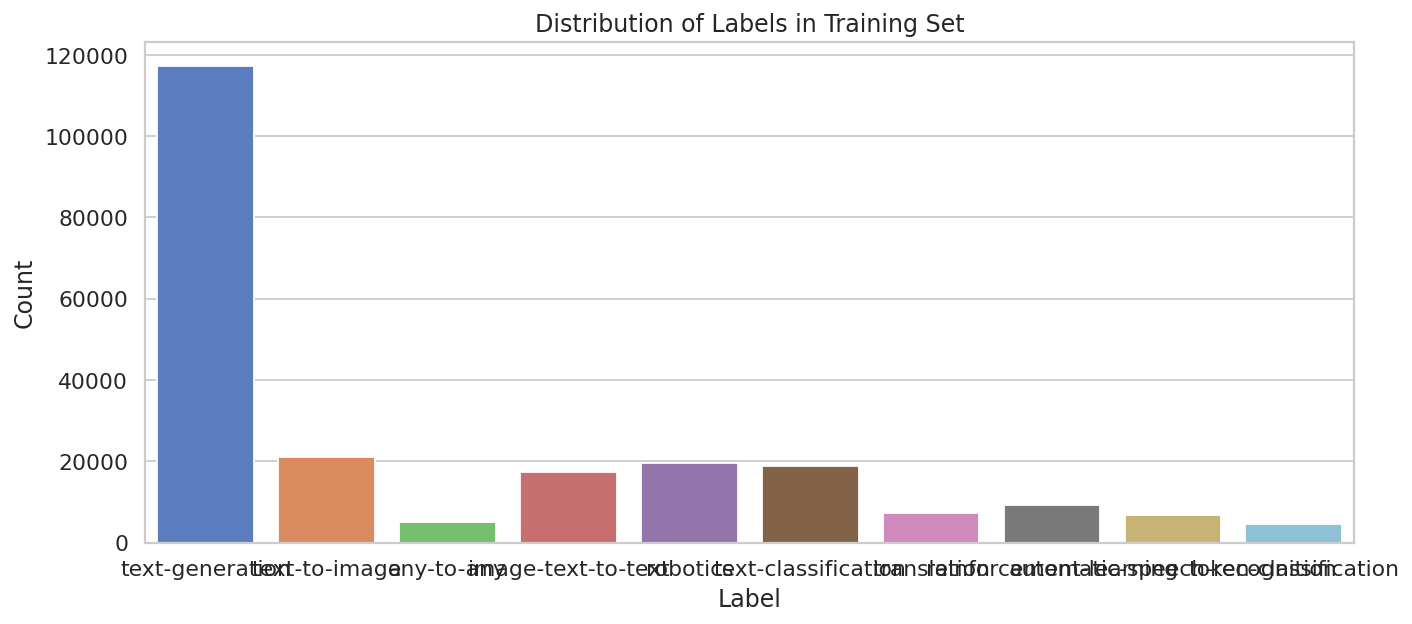

,count
pipeline_tag,
text-generation,117283
text-to-image,21073
robotics,19566
text-classification,18790
image-text-to-text,17320
reinforcement-learning,9259
translation,7301
automatic-speech-recognition,6864
any-to-any,5055


In [ ]:
sns.countplot(x='pipeline_tag', data=train_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

train_df["pipeline_tag"].value_counts()

In [ ]:
sns.countplot(x='pipeline_tag', data=val_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Validation Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

val_df["pipeline_tag"].value_counts()

NameError: name 'sns' is not defined

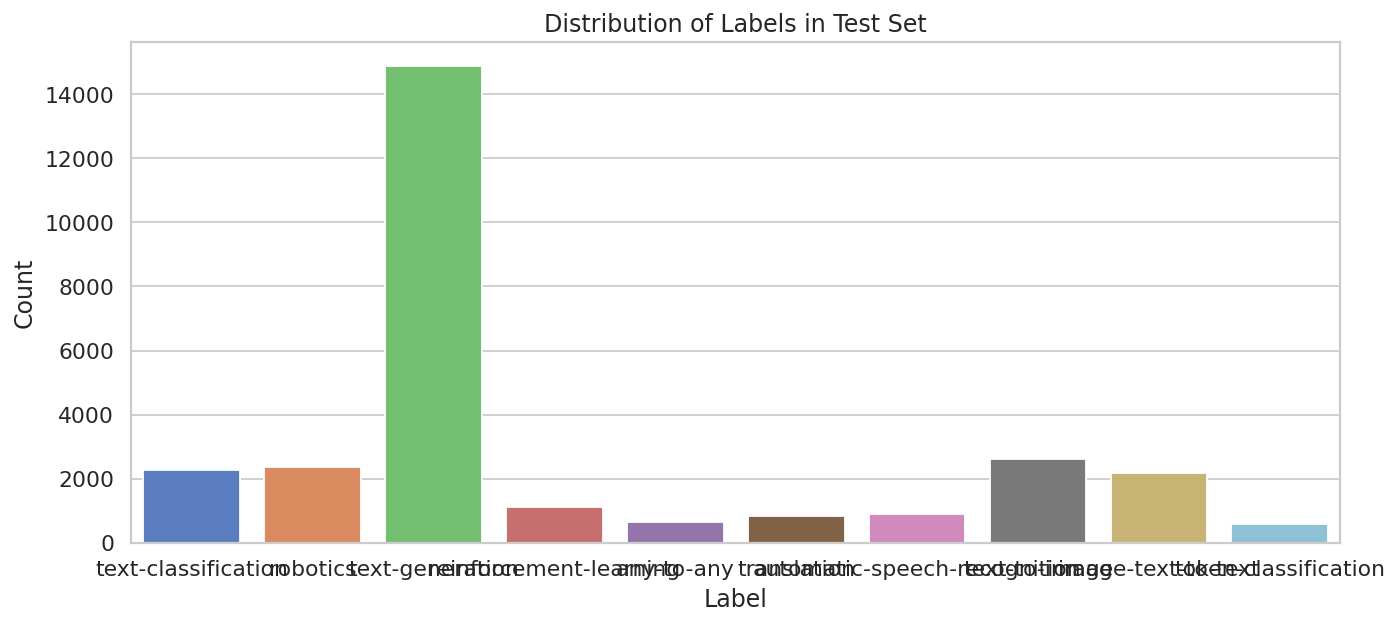

,count
pipeline_tag,
text-generation,14887
text-to-image,2608
robotics,2375
text-classification,2267
image-text-to-text,2178
reinforcement-learning,1114
automatic-speech-recognition,889
translation,838
any-to-any,653


In [ ]:
sns.countplot(x='pipeline_tag', data=test_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Test Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

test_df["pipeline_tag"].value_counts()

In [ ]:
# Define cleaning function
def clean_text(text: str) -> str:
    """Lowercase, remove punctuation/numbers, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# train set
train_df['card_clean']  = train_df['card'].apply(clean_text)
# test set
test_df['card_clean']  = test_df['card'].apply(clean_text)
# validation set
val_df['card_clean']  = val_df['card'].apply(clean_text)

In [ ]:
# Print cleaned example
# raw unformatted:
print(f'\ntrain: raw answer  : "{train_df["card"].iloc[0]}"')


train: raw answer  : "---
license: apache-2.0
language:
- en
tags:
- azure
- cloud-architecture
- qwen3.5
- grpo
- gspo
- reinforcement-learning
- vision-language-model
base_model: unsloth/Qwen3.5-0.8B
datasets:
- thegovind/azure-architecture-grpo-benchmark
- thegovind/azure-architecture-vqa
pipeline_tag: text-generation
---

# Azure Cloud Solution Architect - Qwen 3.5 0.8B (GRPO Merged)

A **fully merged** Qwen 3.5 0.8B model trained with GRPO (Group Relative Policy Optimization) to be an Azure Cloud Solution Architect with structured reasoning capabilities. This is the LoRA adapters merged into the base weights — ready for deployment with no adapter loading needed.

## What This Model Does

- Answers multi-choice Azure architecture questions with structured reasoning
- Produces output in `<REASONING>...</REASONING>` and `<SOLUTION>...</SOLUTION>` format
- References specific Azure services in its reasoning
- Trained with 4 reward signals: format compliance, answer correctness, Azure

In [ ]:
# after cleaning:
print(f'train: clean answer : "{train_df["card_clean"].iloc[0]}"')

train: clean answer : "license apache language en tags azure cloud architecture qwen grpo gspo reinforcement learning vision language model base model unsloth qwen b datasets thegovind azure architecture grpo benchmark thegovind azure architecture vqa pipeline tag text generation azure cloud solution architect qwen b grpo merged a fully merged qwen b model trained with grpo group relative policy optimization to be an azure cloud solution architect with structured reasoning capabilities this is the lora adapters merged into the base weights ready for deployment with no adapter loading needed what this model does answers multi choice azure architecture questions with structured reasoning produces output in reasoning reasoning and solution solution format references specific azure services in its reasoning trained with reward signals format compliance answer correctness azure relevance reasoning quality example output question which azure service handles global load balancing a azure load

## Feature Engineering & Fitting

In [ ]:
# Set TF-IDF
tf_idf_vec = TfidfVectorizer(max_features=50000,
                             ngram_range=(1,2),
                             sublinear_tf=True,
                             stop_words='english',
                             min_df=5
                             )

In [ ]:
label_encoder = LabelEncoder()

# Fit w/ training and val
X_train = tf_idf_vec.fit_transform(train_df["card_clean"])
X_val = tf_idf_vec.transform(val_df["card_clean"])
# Fit w/ test
X_test = tf_idf_vec.transform(test_df["card_clean"])
# Create Y vectors for each set & encode text labels to int categories
Y_train = label_encoder.fit_transform(train_df["pipeline_tag"])
Y_val = label_encoder.transform(val_df["pipeline_tag"])
Y_test = label_encoder.transform(test_df["pipeline_tag"])
# Print shapes
print("Shape of formatted X_train:", X_train.shape)
print("Shape of formatted X_val:", X_val.shape)
print("Shape of formatted X_test:", X_test.shape)
print("Shape of formatted Y_train:", Y_train.shape)
print("Shape of formatted Y_val:", Y_val.shape)
print("Shape of formatted Y_test:", Y_test.shape)

Shape of formatted X_train: (227003, 50000)
Shape of formatted X_val: (28375, 50000)
Shape of formatted X_test: (28376, 50000)
Shape of formatted Y_train: (227003,)
Shape of formatted Y_val: (28375,)
Shape of formatted Y_test: (28376,)


## Baseline

In [ ]:
# Baseline w/ Logistic Regression
lr_model = LogisticRegression(max_iter=1000,
                              class_weight="balanced",
                              random_state=42,
                              n_jobs=-1
                              )

lr_model.fit(X_train, Y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [ ]:
val_predictions = lr_model.predict(X_val)
test_predictions = lr_model.predict(X_test)

In [ ]:
# Analysis
print("Validation Accuracy:", accuracy_score(Y_val, val_predictions))
print("Validation Macro-F1:", f1_score(Y_val, val_predictions, average="macro"))

print("Test Accuracy:", accuracy_score(Y_test, test_predictions))
print("Test Macro-F1:", f1_score(Y_test, test_predictions, average="macro"))

Validation Accuracy: 0.8901497797356828
Validation Macro-F1: 0.910309977207997
Test Accuracy: 0.8885678037778404
Test Macro-F1: 0.9140649593538376


In [ ]:
print(classification_report(Y_test, test_predictions, target_names=label_encoder.classes_))

                              precision    recall  f1-score   support

                  any-to-any       0.92      0.99      0.96       653
automatic-speech-recognition       0.99      0.89      0.93       889
          image-text-to-text       0.86      0.84      0.85      2178
      reinforcement-learning       0.97      1.00      0.98      1114
                    robotics       1.00      1.00      1.00      2375
         text-classification       0.46      0.99      0.63      2267
             text-generation       0.99      0.83      0.90     14887
               text-to-image       1.00      1.00      1.00      2608
        token-classification       0.97      0.85      0.91       567
                 translation       0.98      0.99      0.98       838

                    accuracy                           0.89     28376
                   macro avg       0.91      0.94      0.91     28376
                weighted avg       0.94      0.89      0.90     28376

